In [15]:

import pandas as pd
import seaborn
import seaborn as sns
import xgboost
from catboost import CatBoostRegressor

from xgboost import XGBRegressor
from sklearn.preprocessing import OneHotEncoder,StandardScaler,PolynomialFeatures,PowerTransformer
from sklearn.model_selection import train_test_split,cross_val_score,KFold
import numpy as np
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error,r2_score,root_mean_squared_error
import xgboost as xgb
import matplotlib.pyplot as plt
import lightgbm
from sklearn.linear_model import LinearRegression,Ridge,Lasso
import optuna
from sklearn.model_selection import cross_val_score,cross_validate,cross_val_predict
from statsmodels.api import OLS
import  statsmodels.api as sm
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


In [167]:

def load_data():
    X = pd.read_csv("StudentPerformanceFactors.csv")
    X.drop(columns=["Gender","Sleep_Hours","School_Type"],inplace=True)
    #X=X.dropna().reset_index(drop=True)


    #
    X = X[X["Exam_Score"] <= 100]
    columns = ['Exam_Score']
    outlier_percentage = {}

    for column in columns:
        column_data = X[column]

        Q1 = np.percentile(column_data, 25)
        Q3 = np.percentile(column_data, 75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = column_data[(column_data < lower) | (column_data > upper)]
        outlier_percentage[column] = len(outliers) / len(column_data) * 100
        #X["oudokki"] = np.where((X["Exam_Score"] >= lower) & (X["Exam_Score"] <= upper),1,0)

    y = X["Exam_Score"]

    X.drop(columns=["Exam_Score"], inplace=True)


    return X,y
X,y = load_data()
X


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home
0,23,84,Low,High,No,73,Low,Yes,0,Low,Medium,Positive,3,No,High School,Near
1,19,64,Low,Medium,No,59,Low,Yes,2,Medium,Medium,Negative,4,No,College,Moderate
2,24,98,Medium,Medium,Yes,91,Medium,Yes,2,Medium,Medium,Neutral,4,No,Postgraduate,Near
3,29,89,Low,Medium,Yes,98,Medium,Yes,1,Medium,Medium,Negative,4,No,High School,Moderate
4,19,92,Medium,Medium,Yes,65,Medium,Yes,3,Medium,High,Neutral,4,No,College,Near
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,No,76,Medium,Yes,1,High,Medium,Positive,2,No,High School,Near
6603,23,76,High,Medium,No,81,Medium,Yes,3,Low,High,Positive,2,No,High School,Near
6604,20,90,Medium,Low,Yes,65,Low,Yes,3,Low,Medium,Negative,2,No,Postgraduate,Near
6605,10,86,High,High,Yes,91,High,Yes,2,Low,Medium,Positive,3,No,High School,Far



## ALKAA

R2 Score: 0.7441526733602302
MAE: 0.4663720912626644
R2 OLS: 0.7441526733602297


,feature,coef,abs
7,Access_to_Resources_Low,-2.054673,2.054673
5,Parental_Involvement_Low,-2.047082,2.047082
10,Motivation_Level_Low,-1.169840,1.169840
15,Teacher_Quality_Low,-1.101643,1.101643
13,Family_Income_Low,-1.099473,1.099473
6,Parental_Involvement_Medium,-1.090770,1.090770
8,Access_to_Resources_Medium,-1.038213,1.038213
20,Learning_Disabilities_Yes,-0.760545,0.760545
16,Teacher_Quality_Medium,-0.591590,0.591590
11,Motivation_Level_Medium,-0.586211,0.586211


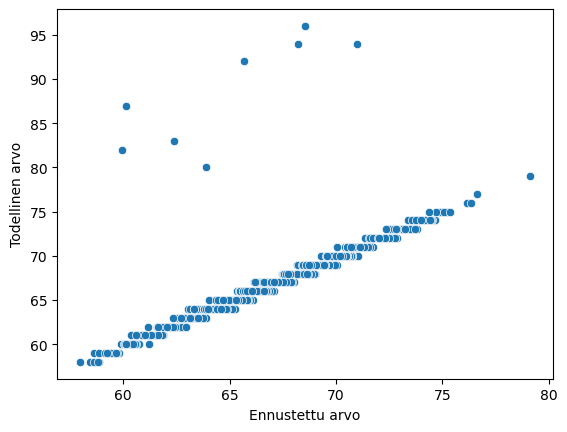

In [168]:
import shap
X,y=load_data()



categorical_columns = X.select_dtypes(include="object").columns.tolist()
numeric = X.select_dtypes(exclude="object").columns.tolist()
encoder = OneHotEncoder(sparse_output=False,drop='first')
imputer = SimpleImputer(strategy='most_frequent')
columns = X.columns.tolist()
X = pd.DataFrame(X,columns=columns)
scaler = StandardScaler()

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=421)



encoded_train = encoder.fit_transform(X_train[categorical_columns])
X_train.drop(columns=categorical_columns,inplace=True)
encoded_names_train = encoder.get_feature_names_out()
X_train = pd.concat(
    [X_train, pd.DataFrame(encoded_train, columns=encoded_names_train, index=X_train.index)],
    axis=1
)
X_train.columns = X_train.columns.astype(str)
#X_train = X_train.astype(float)

#X_train.index=y_train.index

encoded_test = encoder.transform(X_test[categorical_columns])
X_test.drop(columns=categorical_columns,inplace=True)
encoded_names_test = encoder.get_feature_names_out()
X_test = pd.concat(
    [X_test, pd.DataFrame(encoded_test, columns=encoded_names_test, index=X_test.index)],
    axis=1
)
X_test.columns = X_test.columns.astype(str)
#X_test = X_test.astype(float)

#X_test.index=y_test.index


lm = LinearRegression()

lm.fit(X_train,y_train)
preds = lm.predict(X_test)

r2 = r2_score(y_test,preds)
print(f'R2 Score: {r2}')
print(f'MAE: {mean_absolute_error(y_test,preds)}')
coefs = pd.DataFrame({"feature": X_test.columns, "coef": lm.coef_})

X_train = sm.add_constant(X_train)
X_test = sm.add_constant(X_test)
ols =OLS(y_train,X_train)
ols_model = ols.fit()
preds_ols = ols_model.predict(X_test)
r2_ols =r2_score(y_test,preds_ols)
print(f'R2 OLS: {r2_ols}')
ols_model.summary()

coefs.sort_values(by="coef",ascending=False,inplace=True)
coefs

resid = preds - y_test
#plt.scatter(preds,resid)
#plt.ylim((-2,2))
#
#plt.xlabel("Ennustettu arvo")
#plt.ylabel("Jäännös")
#plt.axhline(y=0, color='r', linestyle='-')
coefs["abs"]=coefs["coef"].abs()
coefs.sort_values(by="abs",ascending=True)


res = ols_model.resid # residuals
#Q-Q kuvaaja
#sm.qqplot(res,line='s')
resid_ols = y_test - preds_ols
plt.xlabel("Ennustettu arvo")
plt.ylabel("Todellinen arvo")
sns.scatterplot(x=preds_ols,y=y_test)
#plt.axhline(y=0, color='r', linestyle='-')
#plt.ylim(50,96)
#plt.xlim(50,100)
#ols_model.summary()
(coefs.sort_values(by="coef",ascending=True))



In [141]:
X,y = load_data()
X["Exam_Score"]=y
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=421)



encoded_train = encoder.fit_transform(X_train[categorical_columns])
X_train.drop(columns=categorical_columns,inplace=True)
encoded_names_train = encoder.get_feature_names_out()
X_train = pd.concat(
    [X_train, pd.DataFrame(encoded_train, columns=encoded_names_train, index=X_train.index)],
    axis=1
)
X_train.columns = X_train.columns.astype(str)
#X_train = X_train.astype(float)

X_train.index=y_train.index
pd.DataFrame(X_train.corr()).sort_values(by="Exam_Score",ascending=False)


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score,Parental_Involvement_Low,Parental_Involvement_Medium,Access_to_Resources_Low,...,Peer_Influence_Neutral,Peer_Influence_Positive,Learning_Disabilities_Yes,Parental_Education_Level_High School,Parental_Education_Level_Postgraduate,Parental_Education_Level_nan,Distance_from_Home_Moderate,Distance_from_Home_Near,Distance_from_Home_nan,Gender_Male
Exam_Score,0.437955,0.578433,-0.014900,0.173924,0.151386,0.017395,1.000000,-0.116513,-0.035666,-0.128972,...,-0.010121,0.083238,-0.075295,-0.095070,0.095573,-0.006759,-0.036465,0.088414,-0.019389,-0.004196
Attendance,-0.017793,1.000000,-0.016593,-0.020466,0.005772,-0.030255,0.578433,0.015848,-0.005797,0.012062,...,0.028262,-0.016573,-0.024681,-0.021092,0.020439,-0.001123,-0.016097,0.028694,-0.018072,0.006032
Hours_Studied,1.000000,-0.017793,0.012985,0.019820,-0.006498,0.003678,0.437955,0.017100,-0.001298,0.011049,...,-0.006403,0.008172,-0.001287,-0.000154,-0.002699,0.019773,0.023520,-0.015426,-0.013909,-0.020179
Previous_Scores,0.019820,-0.020466,-0.021462,1.000000,-0.014792,-0.010220,0.173924,0.010938,0.003750,-0.027425,...,0.011006,-0.017443,0.003715,0.018735,0.003831,-0.025599,-0.001867,0.003160,-0.008215,-0.003074
Tutoring_Sessions,-0.006498,0.005772,-0.009054,-0.014792,1.000000,0.014529,0.151386,0.012150,-0.018897,0.013898,...,0.001355,0.002558,0.002813,-0.009707,0.011951,-0.016692,-0.013218,0.022903,0.008151,-0.002984
Parental_Education_Level_Postgraduate,-0.002699,0.020439,0.005194,0.003831,0.011951,-0.024948,0.095573,0.003744,0.012385,0.005156,...,0.005648,0.008524,-0.004840,-0.483100,1.000000,-0.054410,-0.000097,0.004221,-0.000231,-0.002625
Distance_from_Home_Near,-0.015426,0.028694,-0.005817,0.003160,0.022903,0.004228,0.088414,-0.007694,0.011933,-0.011101,...,0.026538,-0.027819,0.007355,0.022418,0.004221,-0.008226,-0.785172,1.000000,-0.119003,0.003736
Peer_Influence_Positive,0.008172,-0.016573,-0.018517,-0.017443,0.002558,0.006425,0.083238,-0.002753,-0.011087,-0.011057,...,-0.662112,1.000000,-0.002735,-0.005628,0.008524,-0.015954,0.028777,-0.027819,-0.014338,0.001084
Extracurricular_Activities_Yes,-0.002959,0.003392,-0.001996,0.008826,0.007699,-0.006409,0.071868,0.015124,0.009154,0.012808,...,-0.024504,0.017024,-0.006174,0.000623,-0.007746,-0.005404,0.019874,-0.015803,0.010357,0.018745
Internet_Access_Yes,0.014581,-0.016677,0.014807,-0.002580,-0.009985,-0.012896,0.063880,-0.016310,0.015550,0.019838,...,0.008239,-0.019406,0.005867,0.015679,0.000355,0.018368,-0.003515,0.000184,0.006425,0.014180


In [ ]:

X,y = load_data()
categorical_columns = X.select_dtypes(include="object").columns.tolist()
numeric_features = X.select_dtypes(exclude="object").columns.tolist()
# Define preprocessing for categorical and numeric columns
preprocessor = ColumnTransformer(
    transformers=[
        # One-hot encode categorical features, ignore unseen categories at prediction time
        ("cat", OneHotEncoder(handle_unknown="ignore",drop="first"), categorical_columns),
        # Standardize numeric features (zero mean, unit variance)
        ("num", StandardScaler(), numeric_features),
    ]
)

# Set up a linear regression model
regressor = LinearRegression(

)

# Combine preprocessing and regression into a single pipeline
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),  # First apply transformations
        ("regressor", regressor),        # Then fit/predict with linear regression
    ]
)
scores = cross_val_score(model,X,y,cv=5,scoring="r2",n_jobs=-1)
np.mean(scores)



0.7309297096226393

Text(0, 0.5, 'Exam Score')

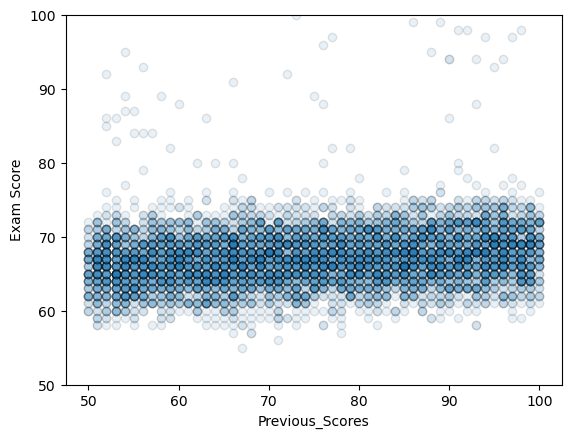

In [127]:
X,y = load_data()
plt.scatter(X["Previous_Scores"],y,alpha=0.1,edgecolor="k")
plt.ylim([50,100])
plt.xlabel("Previous_Scores")
plt.ylabel("Exam Score")

Text(0.5, 1.0, 'Poikkeavat havainnot poistettu')

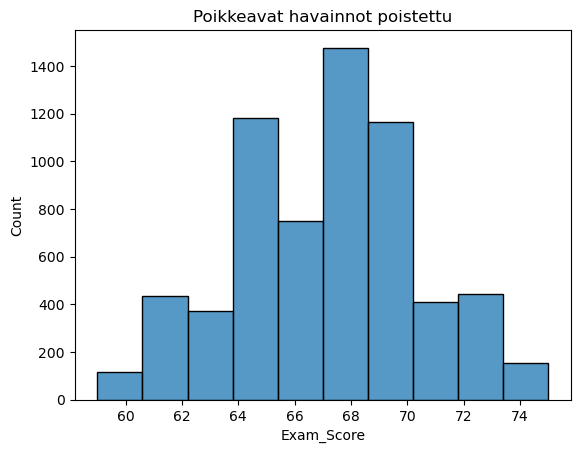

In [329]:
sns.histplot(y,bins=10)

plt.title("Poikkeavat havainnot poistettu")


## LOPPUU

In [16]:
 X,y = load_data()
# #y=np.log(y)
 categorical_columns = X.select_dtypes(include="object").columns.tolist()
 X[categorical_columns] = X[categorical_columns].astype("category")
 X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42,shuffle=True)
 X_test,X_validation,y_test,y_validation = train_test_split(X_test,y_test,test_size=0.5,random_state=42)
 model = XGBRegressor(n_estimators=1500,learning_rate=0.02,enable_categorical=True,reg_lambda=10,random_state=42,early_stopping_rounds = 50)
 model.fit(X_train,y_train,eval_set=[(X_validation,y_validation)],verbose=100)
 preds = model.predict(X_test)

 resid = preds-y_test
 r2 = r2_score(y_test,preds)

 print(f'MSE: {mean_absolute_error(y_test,preds)}')
 print(f'R2 full {r2} ')

# resid = y_test-preds
# xgboost.plot_importance(model)
# #sns.scatterplot(x=preds,y=y_test,hue  =resid)

[0]	validation_0-rmse:3.22987
[100]	validation_0-rmse:1.45781
[200]	validation_0-rmse:1.05291
[300]	validation_0-rmse:0.85881
[400]	validation_0-rmse:0.75258
[500]	validation_0-rmse:0.69178
[600]	validation_0-rmse:0.65595
[700]	validation_0-rmse:0.63479
[800]	validation_0-rmse:0.62059
[900]	validation_0-rmse:0.61106
[1000]	validation_0-rmse:0.60450
[1100]	validation_0-rmse:0.59945
[1200]	validation_0-rmse:0.59485
[1300]	validation_0-rmse:0.59157
[1400]	validation_0-rmse:0.58909
[1499]	validation_0-rmse:0.58671
MSE: 0.4458396794245793
R2 full 0.9689467549324036 


## CAT

In [421]:
X,y = load_data()
y=np.log(y)
categorical_columns = X.select_dtypes(include=['object']).columns.tolist()
X[categorical_columns] = X[categorical_columns].fillna("NaN")
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42,shuffle=True)
X_test,X_validation,y_test,y_validation = train_test_split(X_test,y_test,test_size=0.5,random_state=42)
model_cat =CatBoostRegressor(use_best_model=True,early_stopping_rounds=50)
model_cat.fit(X_train,y_train,cat_features=categorical_columns,eval_set=[(X_validation,y_validation)],verbose=100)
preds = model_cat.predict(X_test)
r2_test=r2_score(y_test,preds)
preds_full =model_cat.predict(X)
r2_full = r2_score(y,preds_full)
rmse = root_mean_squared_error(y_test,preds)
rmse_full = root_mean_squared_error(y,preds_full)
print(f'R2 test {r2_test} ')
print(f'R2 full {r2_full} ')
print(f'RMSE test {rmse} ')
print(f'RMSE full {rmse_full} ')


Learning rate set to 0.0646
0:	learn: 0.0466317	test: 0.0469212	best: 0.0469212 (0)	total: 199ms	remaining: 3m 18s
100:	learn: 0.0105483	test: 0.0110658	best: 0.0110658 (100)	total: 2.41s	remaining: 21.5s
200:	learn: 0.0066857	test: 0.0070138	best: 0.0070138 (200)	total: 4.99s	remaining: 19.8s
300:	learn: 0.0054695	test: 0.0060514	best: 0.0060514 (300)	total: 8.02s	remaining: 18.6s
400:	learn: 0.0049712	test: 0.0057863	best: 0.0057863 (400)	total: 10.7s	remaining: 15.9s
500:	learn: 0.0046679	test: 0.0056279	best: 0.0056278 (498)	total: 13.3s	remaining: 13.3s
600:	learn: 0.0044455	test: 0.0055485	best: 0.0055485 (600)	total: 16.3s	remaining: 10.8s
700:	learn: 0.0042754	test: 0.0054873	best: 0.0054869 (699)	total: 19.5s	remaining: 8.33s
800:	learn: 0.0041277	test: 0.0054422	best: 0.0054422 (800)	total: 22.4s	remaining: 5.57s
900:	learn: 0.0039877	test: 0.0054147	best: 0.0054147 (900)	total: 25.3s	remaining: 2.77s
999:	learn: 0.0038635	test: 0.0053964	best: 0.0053964 (999)	total: 28.1s	re

## LGBM

In [ ]:

X,y =  load_data()
y=np.log(y)
categorical_columns = X.select_dtypes(include=['object']).columns.tolist()
X[categorical_columns] = X[categorical_columns].astype("category")

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42,shuffle=True)
X_test,X_validation,y_test,y_validation = train_test_split(X_test,y_test,test_size=0.5,random_state=42)
params = {'learning_rate': 0.0970688720107848, 'num_leaves': 20, 'feature_fraction': 0.7206082609076269, 'max_depth': 4}
model = lightgbm.LGBMRegressor(**params,random_state=42,early_stopping_rounds = 50,n_estimators=5000)
model.fit(X_train,y_train,categorical_feature=categorical_columns,eval_set=[(X_validation,y_validation)])
preds = model.predict(X_test)
preds_full = model.predict(X)
r2 = r2_score(y_test,preds)
r2_full = r2_score(y,preds_full)
rmse = root_mean_squared_error(y_test,preds)
rmse_full = root_mean_squared_error(y,preds_full)
print(f'R2 test {r2_test} ')
print(f'R2 full {r2_full} ')
print(f'RMSE test {rmse} ')
print(f'RMSE full {rmse_full} ')
